# LAB06 — Simulation & plots

- Double-link pendulum simulation 
- Boat model simulation + plots
- Differential drive simulation + plots



## Setup

Imports, plotting functions


In [39]:
from pathlib import Path
from collections import deque

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import FileLink, display
from scipy.integrate import solve_ivp

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

CWD = Path.cwd().resolve()
if (CWD / "LAB06").exists():
    REPO_ROOT = CWD
elif CWD.name == "LAB06":
    REPO_ROOT = CWD.parent
else:
    REPO_ROOT = CWD

EXPORT_DIR = REPO_ROOT / "LAB06" / "exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Exports folder: {EXPORT_DIR.resolve()}")


Exports folder: /Users/anashamrouni/Documents/InnopolisUniversity/Bachelor/RoboticSystems/LAB06/exports


## 1) Utility functions

Reusable helpers: integration wrapper, plotting helpers, animation helper, and MP4 export.


In [40]:
def export_animation_media(ani, basename: str, fps: float, *, also_html: bool = True):
    """Export a matplotlib animation.

    Why this exists: the lab report needs a saved video (MP4). We also save HTML for easy viewing.

    - MP4 uses ffmpeg.
    - If MP4 fails, we fall back to GIF (pillow).
    """
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    stem = EXPORT_DIR / basename
    saved = []

    # Grab figure so we can close it after export (keeps notebook responsive).
    fig = getattr(ani, "_fig", None)

    fps_eff = float(min(max(fps, 1e-6), 120.0))

    mp4_path = stem.with_suffix(".mp4")
    try:
        ani.save(str(mp4_path), writer=animation.FFMpegWriter(fps=fps_eff), dpi=100)
        saved.append(mp4_path)
        print(f"Saved: {mp4_path}")
    except Exception as e:
        print(f"MP4 export failed ({e}); trying GIF…")
        gif_path = stem.with_suffix(".gif")
        try:
            ani.save(str(gif_path), writer=animation.PillowWriter(fps=min(fps_eff, 50.0)), dpi=90)
            saved.append(gif_path)
            print(f"Saved: {gif_path}")
        except Exception as e2:
            print(f"GIF export failed: {e2}")

    if also_html:
        html_path = stem.with_suffix(".html")
        html_path.write_text(ani.to_jshtml(), encoding="utf-8")
        saved.append(html_path)
        print(f"Saved: {html_path}")

    if fig is not None:
        plt.close(fig)

    # Show clickable links in notebook output.
    print("Exported files:", [p.name for p in saved])
    for p in saved:
        try:
            display(FileLink(str(p.relative_to(Path.cwd()))))
        except ValueError:
            display(FileLink(str(p.resolve())))
    return saved


def integrate_system(rhs, y0, t_eval, max_step=0.01):
    """Thin wrapper around solve_ivp with tight tolerances.

    We keep tolerances relatively strict because constraint-based dynamics can drift if the
    integrator is too loose.
    """
    return solve_ivp(
        rhs,
        (t_eval[0], t_eval[-1]),
        y0,
        t_eval=t_eval,
        max_step=max_step,
        rtol=1e-8,
        atol=1e-10,
    )


def plot_xy(t, x, y, title, ylabel):
    fig, ax = plt.subplots(1, 1, figsize=(10, 3.5))
    ax.plot(t, x, label="x")
    ax.plot(t, y, label="y")
    ax.set_xlabel("time [s]")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc="upper right")
    plt.tight_layout()


def plot_points_xy(t, points, labels, title, *, y_unit: str = "m"):
    """Plot (x(t), y(t)) for multiple points.

    y_unit controls the displayed unit on the y-axis (e.g. "m" for coordinates, "m/s" for velocities).
    """
    fig, axes = plt.subplots(len(points), 1, figsize=(10, 2.8 * len(points)), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, (x, y), label in zip(axes, points, labels):
        ax.plot(t, x, label=f"{label}: x")
        ax.plot(t, y, label=f"{label}: y")
        ax.set_ylabel(y_unit)
        ax.legend(loc="upper right")
    axes[-1].set_xlabel("time [s]")
    fig.suptitle(title)
    plt.tight_layout()


def visualize_double_pendulum(points, stats=None, dt=0.01, trace_len=0.1, axes=False):
    """Animate a planar 2-link pendulum given point trajectories.

    points: [(x0,y0),(x1,y1),(x2,y2)] or [(x1,y1),(x2,y2)] with x0=y0=0 assumed.
    stats: list of (name, array_like) to show in the corner.
    """
    if len(points) == 2:
        x0 = np.zeros_like(points[0][0])
        y0 = np.zeros_like(points[0][1])
        x1, y1 = points[0]
        x2, y2 = points[1]
    elif len(points) == 3:
        (x0, y0), (x1, y1), (x2, y2) = points
    else:
        raise ValueError("points must contain either 2 or 3 planar points")

    LEN = len(x1)

    all_x = np.concatenate([x0, x1, x2])
    all_y = np.concatenate([y0, y1, y2])
    L_MAX = 1.1 * max(np.max(np.abs(all_x)), np.max(np.abs(all_y)), 1.0)

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(autoscale_on=False, xlim=(-L_MAX, L_MAX), ylim=(-L_MAX, L_MAX))
    ax.set_aspect("equal", adjustable="box")
    if axes:
        ax.grid(color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    else:
        plt.axis("off")

    line, = ax.plot([], [], "-", c="black", lw=2)
    circle_0, = ax.plot([], [], "o", c="black", markersize=6, zorder=5)
    circle_1, = ax.plot([], [], "o", c="blue", markersize=6, zorder=5)
    circle_2, = ax.plot([], [], "o", c="red", markersize=6, zorder=5)

    trace, = ax.plot([], [], "-", c="r", lw=1, alpha=0.2)
    corner_text = ax.text(0.05, 0.8, "", transform=ax.transAxes, zorder=10)

    history_x, history_y = deque(maxlen=int(trace_len * LEN)), deque(maxlen=int(trace_len * LEN))

    def animate(i):
        thisx = [x0[i], x1[i], x2[i]]
        thisy = [y0[i], y1[i], y2[i]]

        if i == 0:
            history_x.clear()
            history_y.clear()

        history_x.appendleft(thisx[2])
        history_y.appendleft(thisy[2])

        line.set_data(thisx, thisy)
        circle_0.set_data([x0[i]], [y0[i]])
        circle_1.set_data([x1[i]], [y1[i]])
        circle_2.set_data([x2[i]], [y2[i]])
        trace.set_data(history_x, history_y)

        if stats is not None:
            stat_text = ""
            for name, series in stats:
                stat_text += rf"{name}: {float(series[i]):.3f}" + "\n"
            corner_text.set_text(stat_text.rstrip())

        return circle_0, circle_1, circle_2, line, trace, corner_text

    ani = animation.FuncAnimation(fig, animate, interval=dt * 1000, frames=LEN, blit=True)
    return ani


## 2) Double pendulum (angle-based model)

Simulate the standard double-pendulum ODE , then compute point trajectories.


In [41]:
# System parameters
m1 = 1.0
m2 = 1.0
l1 = 0.8
l2 = 1.2
g = 9.8

# Simulation time grid
T_STOP = 20.0
dt = 0.01
t = np.arange(0.0, T_STOP + dt, dt)

# Initial condition (angles in radians, measured from vertical downward)
θ1_0 = np.deg2rad(120.0)
θ2_0 = np.deg2rad(60.0)
ω1_0 = 0.0
ω2_0 = 0.0

y0 = np.array([θ1_0, ω1_0, θ2_0, ω2_0], dtype=float)


In [42]:
def rhs_double_pendulum(t, y, *, m1, m2, l1, l2, g):
    """Standard double pendulum dynamics in (θ1, ω1, θ2, ω2).

    Angles are absolute, measured from vertical downward.
    """
    θ1, ω1, θ2, ω2 = y

    Δ = θ1 - θ2
    denom1 = l1 * (2.0 * m1 + m2 - m2 * np.cos(2.0 * Δ))
    denom2 = l2 * (2.0 * m1 + m2 - m2 * np.cos(2.0 * Δ))

    dθ1 = ω1
    dθ2 = ω2

    dω1 = (
        -g * (2.0 * m1 + m2) * np.sin(θ1)
        - m2 * g * np.sin(θ1 - 2.0 * θ2)
        - 2.0 * np.sin(Δ) * m2 * (ω2 ** 2 * l2 + ω1 ** 2 * l1 * np.cos(Δ))
    ) / denom1

    dω2 = (
        2.0 * np.sin(Δ)
        * (
            ω1 ** 2 * l1 * (m1 + m2)
            + g * (m1 + m2) * np.cos(θ1)
            + ω2 ** 2 * l2 * m2 * np.cos(Δ)
        )
    ) / denom2

    return np.array([dθ1, dω1, dθ2, dω2], dtype=float)


sol = integrate_system(
    lambda tt, yy: rhs_double_pendulum(tt, yy, m1=m1, m2=m2, l1=l1, l2=l2, g=g),
    y0,
    t,
    max_step=dt,
)

if not sol.success:
    raise RuntimeError(sol.message)

θ1 = sol.y[0]
ω1 = sol.y[1]
θ2 = sol.y[2]
ω2 = sol.y[3]

t = sol.t
print("Integrated samples:", t.size)


Integrated samples: 2002


In [43]:
# Compute positions of points 0, 1, 2
x0 = np.zeros_like(t)
y0p = np.zeros_like(t)

x1 = l1 * np.sin(θ1)
y1 = -l1 * np.cos(θ1)

x2 = x1 + l2 * np.sin(θ2)
y2 = y1 - l2 * np.cos(θ2)

# Velocities of points 0, 1, 2
vx0 = np.zeros_like(t)
vy0 = np.zeros_like(t)

vx1 = l1 * ω1 * np.cos(θ1)
vy1 = l1 * ω1 * np.sin(θ1)

vx2 = vx1 + l2 * ω2 * np.cos(θ2)
vy2 = vy1 + l2 * ω2 * np.sin(θ2)

# Link lengths (displayed in animation)
L1 = np.sqrt((x1 - x0) ** 2 + (y1 - y0p) ** 2)
L2 = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

print("L1 range:", float(L1.min()), float(L1.max()))
print("L2 range:", float(L2.min()), float(L2.max()))


L1 range: 0.7999999999999999 0.8000000000000003
L2 range: 1.1999999999999995 1.2000000000000004


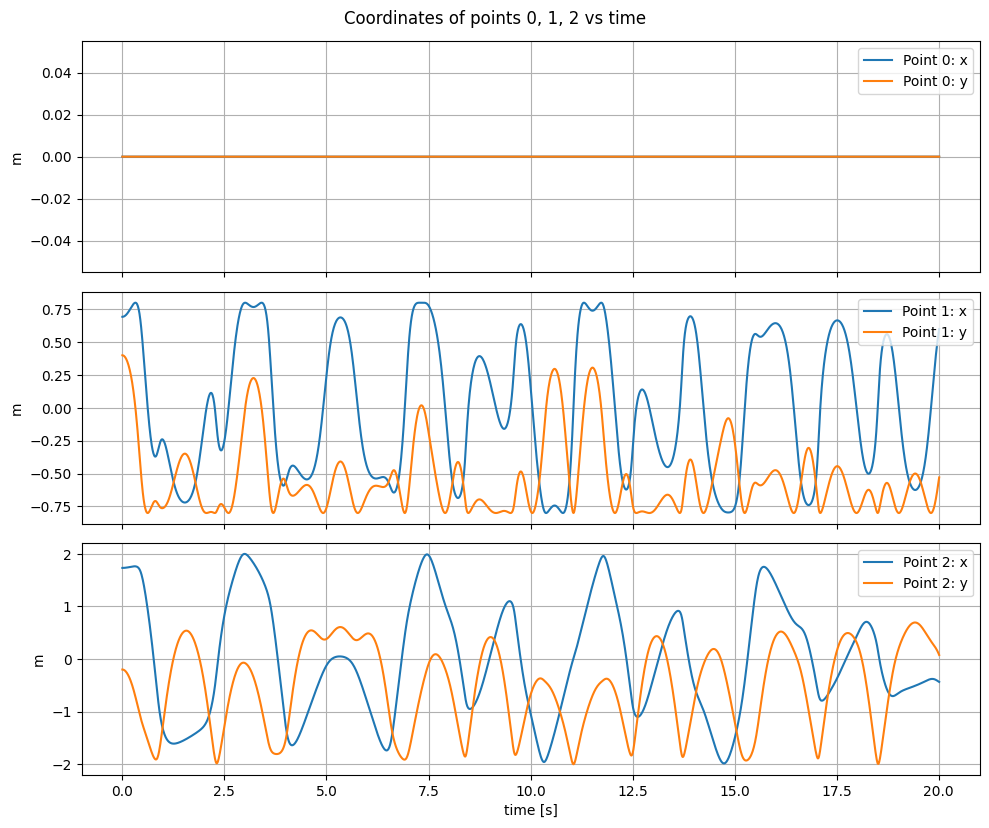

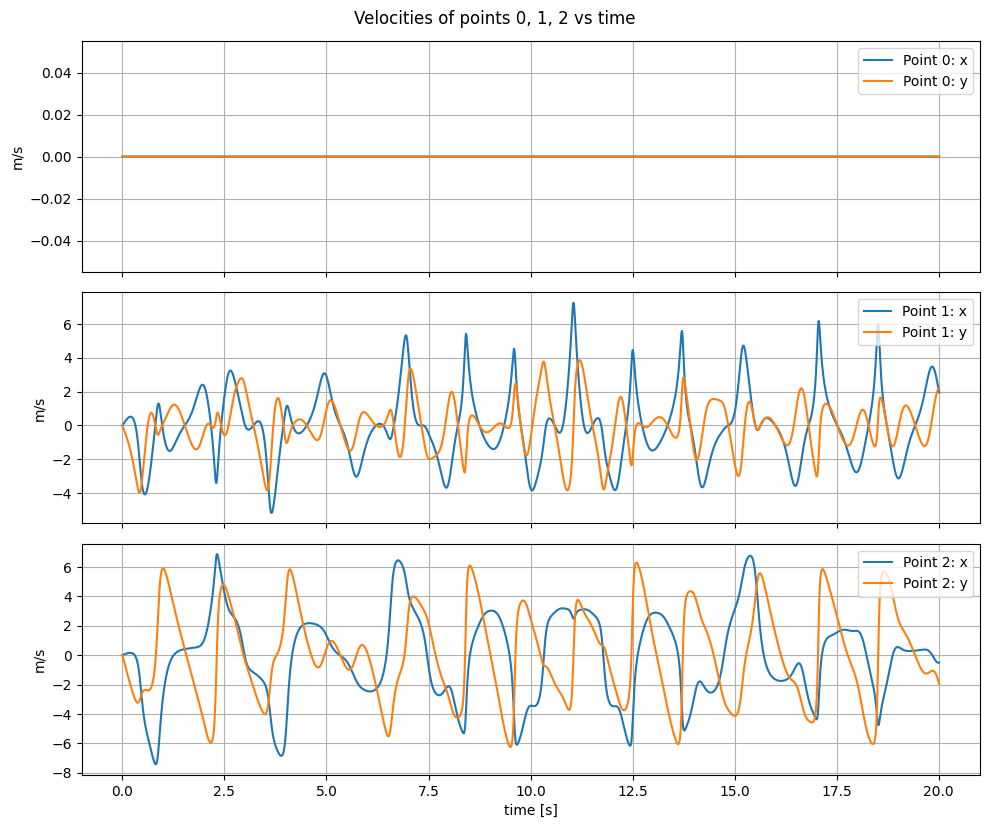

In [44]:
# Plots: coordinates vs time
plot_points_xy(
    t,
    points=[(x0, y0p), (x1, y1), (x2, y2)],
    labels=["Point 0", "Point 1", "Point 2"],
    title="Coordinates of points 0, 1, 2 vs time",
    y_unit="m",
)

# Plots: velocities vs time
plot_points_xy(
    t,
    points=[(vx0, vy0), (vx1, vy1), (vx2, vy2)],
    labels=["Point 0", "Point 1", "Point 2"],
    title="Velocities of points 0, 1, 2 vs time",
    y_unit="m/s",
)


## 3) Visualization + export

- Plot point coordinates/velocities vs time
- Animate the motion with \(L_1, L_2\) displayed
- Export to MP4


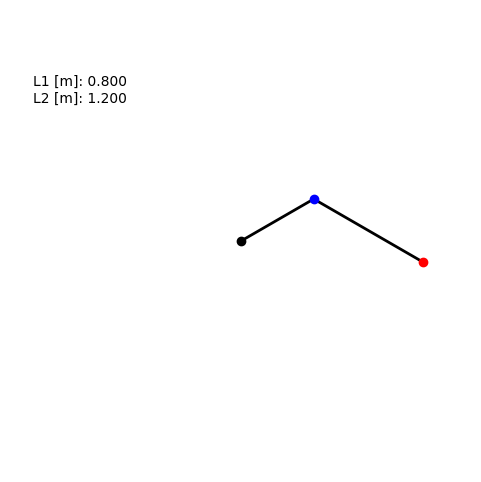

In [45]:
# Animation (with link lengths displayed)
points = [(x0, y0p), (x1, y1), (x2, y2)]
stats = [("L1 [m]", L1), ("L2 [m]", L2)]

ani = visualize_double_pendulum(points, stats=stats, dt=dt, trace_len=0.25, axes=False)
ani


In [46]:
# Export animation 
fps = 1.0 / dt
export_animation_media(ani, "double_pendulum", fps=fps)


Saved: /Users/anashamrouni/Documents/InnopolisUniversity/Bachelor/RoboticSystems/LAB06/exports/double_pendulum.mp4


Animation size has reached 20985020 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


Saved: /Users/anashamrouni/Documents/InnopolisUniversity/Bachelor/RoboticSystems/LAB06/exports/double_pendulum.html
Exported files: ['double_pendulum.mp4', 'double_pendulum.html']


/Users/anashamrouni/Documents/InnopolisUniversity/Bachelor/RoboticSystems/LAB06/exports/double_pendulum.mp4

/Users/anashamrouni/Documents/InnopolisUniversity/Bachelor/RoboticSystems/LAB06/exports/double_pendulum.html

[PosixPath('/Users/anashamrouni/Documents/InnopolisUniversity/Bachelor/RoboticSystems/LAB06/exports/double_pendulum.mp4'),
 PosixPath('/Users/anashamrouni/Documents/InnopolisUniversity/Bachelor/RoboticSystems/LAB06/exports/double_pendulum.html')]

## 5) Task 2.3 — Boat model (simulation + plots)

Simulate the boat model, plot time histories, and check the constraint residual.


In [47]:
def msqrt_and_invsqrt(M: np.ndarray):
    """Return (M^{1/2}, M^{-1/2}) for SPD M using eigen-decomposition."""
    w, V = np.linalg.eigh(M)
    if np.any(w <= 0):
        raise ValueError("M must be symmetric positive definite")
    Wsqrt = np.diag(np.sqrt(w))
    Winvsqrt = np.diag(1.0 / np.sqrt(w))
    Msqrt = V @ Wsqrt @ V.T
    Minvsqrt = V @ Winvsqrt @ V.T
    return Msqrt, Minvsqrt


def udwadia_kalaba_accel(M: np.ndarray, Qs: np.ndarray, A: np.ndarray, b: np.ndarray):
    """formula: qdd = a + M^{-1/2} (A M^{-1/2})^† (b - A a)."""
    Msqrt, Minvsqrt = msqrt_and_invsqrt(M)
    a = np.linalg.solve(M, Qs)
    AMi = A @ Minvsqrt
    correction = Minvsqrt @ (np.linalg.pinv(AMi) @ (b - A @ a))
    qdd = a + correction
    Qc = Msqrt @ (np.linalg.pinv(AMi) @ (b - A @ a))
    return qdd, Qc


def finite_diff(t, x):
    """numerical derivative with same length output."""
    dx = np.gradient(x, t)
    return dx


In [48]:
# Boat parameters 
m = 5.0       # mass [kg]
Izz = 1.0     # yaw inertia [kg m^2]

# External generalized forces Qs = [Fx, Fy, τ]^T (world frame)
# We'll apply a thrust along the boat body x-axis and a mild steering torque.
F_thrust = 2.0
τ_steer = 0.4

# Time grid
T_BOAT = 20.0
dt_boat = 0.01
tb = np.arange(0.0, T_BOAT + dt_boat, dt_boat)

# Initial pose and velocity
q0_boat = np.array([0.0, 0.0, np.deg2rad(20.0)])
qd0_boat = np.array([0.5, 0.0, 0.0])  # initial world velocity guess

M_boat = np.diag([m, m, Izz]).astype(float)


def boat_constraint_A_b(q, qd):
    """No-sideslip: -sinθ xdot + cosθ ydot = 0 -> A qdd = b."""
    x, y, θ = q
    xd, yd, θd = qd

    A = np.array([[-np.sin(θ), np.cos(θ), 0.0]], dtype=float)  # 1x3

    # psi = -sinθ*xd + cosθ*yd
    # ∂psi/∂θ = -(cosθ*xd + sinθ*yd)
    dpsi_dθ = -(np.cos(θ) * xd + np.sin(θ) * yd)

    # b = -(∂psi/∂q qdot) = -(∂psi/∂θ * θdot)
    b = np.array([-(dpsi_dθ * θd)], dtype=float)
    return A, b


def boat_Qs(q, qd, t):
    """Thrust along body x-axis + steering torque."""
    _, _, θ = q
    Fx = F_thrust * np.cos(θ)
    Fy = F_thrust * np.sin(θ)
    return np.array([Fx, Fy, τ_steer], dtype=float)


def rhs_boat(t, y):
    # y = [q(3), qd(3)]
    q = y[:3]
    qd = y[3:]

    A, b = boat_constraint_A_b(q, qd)
    Qs = boat_Qs(q, qd, t)
    qdd, _Qc = udwadia_kalaba_accel(M_boat, Qs, A, b)

    return np.concatenate([qd, qdd])


y0_boat = np.concatenate([q0_boat, qd0_boat])
sol_boat = integrate_system(rhs_boat, y0_boat, tb, max_step=dt_boat)
if not sol_boat.success:
    raise RuntimeError(sol_boat.message)

qb = sol_boat.y[:3]
qdb = sol_boat.y[3:]

xb, yb, θb = qb
vxb, vyb, ωb = qdb
print("Boat sim samples:", sol_boat.t.size)


Boat sim samples: 2002


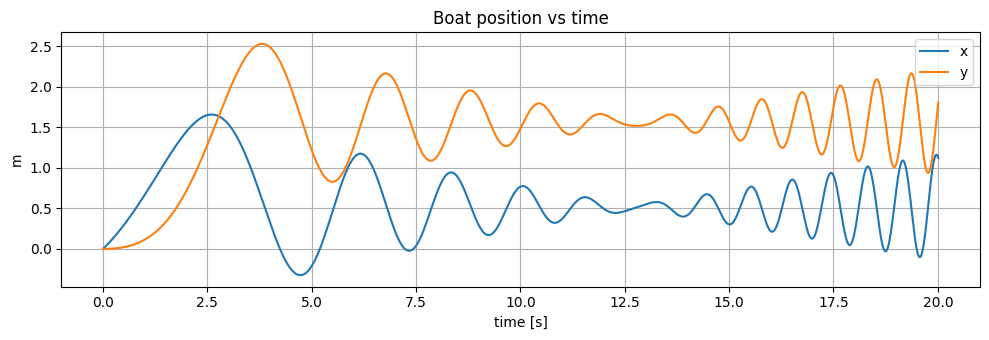

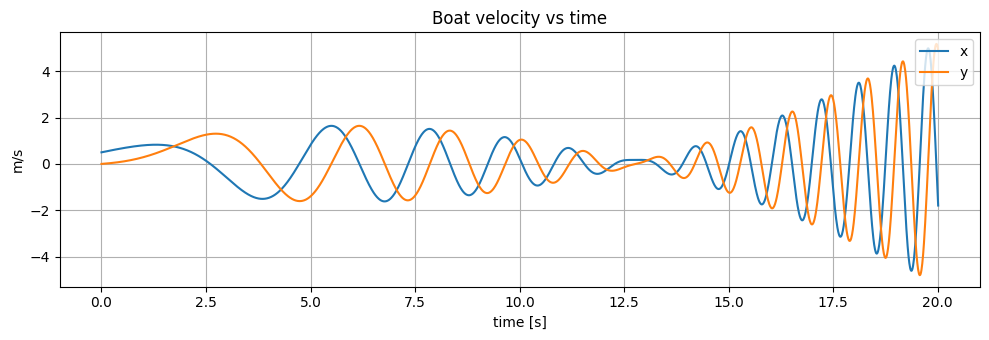

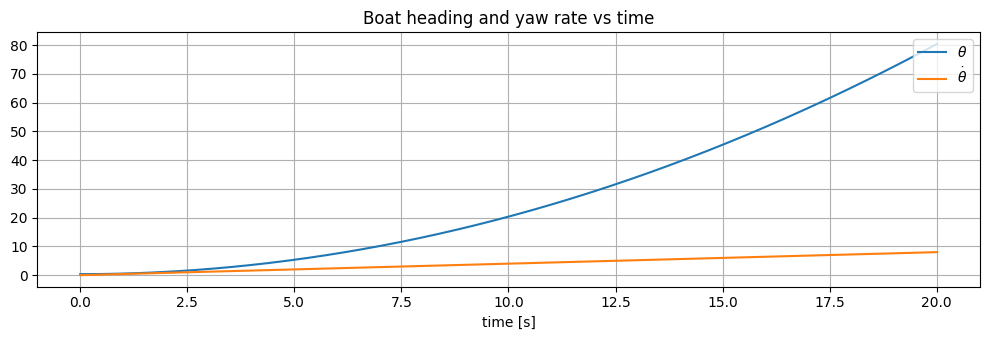

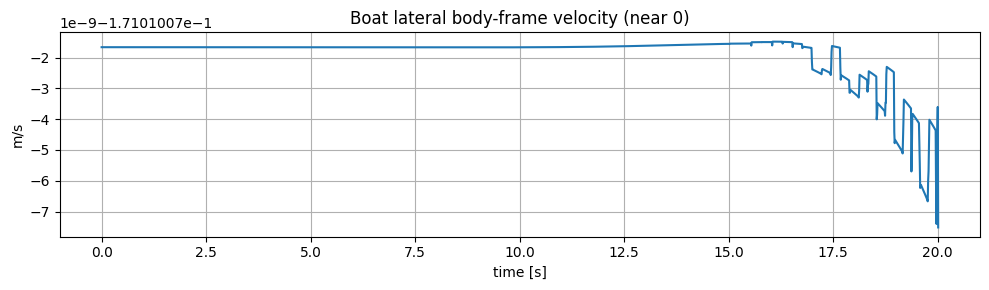

In [49]:
# Boat plots: coordinates and velocities vs time
plot_xy(sol_boat.t, xb, yb, title="Boat position vs time", ylabel="m")
plot_xy(sol_boat.t, vxb, vyb, title="Boat velocity vs time", ylabel="m/s")

fig, ax = plt.subplots(1, 1, figsize=(10, 3.5))
ax.plot(sol_boat.t, θb, label=r"$\theta$")
ax.plot(sol_boat.t, ωb, label=r"$\dot\theta$")
ax.set_xlabel("time [s]")
ax.set_title("Boat heading and yaw rate vs time")
ax.legend(loc="upper right")
plt.tight_layout()

# lateral velocity in body frame should be ~0
v_lat = -np.sin(θb) * vxb + np.cos(θb) * vyb
fig, ax = plt.subplots(1, 1, figsize=(10, 3.0))
ax.plot(sol_boat.t, v_lat)
ax.set_title("Boat lateral body-frame velocity (near 0)")
ax.set_xlabel("time [s]")
ax.set_ylabel("m/s")
plt.tight_layout()


## 6) Task 2.4 — Differential drive (simulation + plots)

Simulate the lecture differential-drive model, plot time histories, and check constraint residuals.


In [50]:
# Differential drive parameters
m_dd = 8.0       # chassis mass [kg]
Izz_dd = 1.2     # chassis yaw inertia [kg m^2]
Iw = 0.05        # wheel inertia [kg m^2]
rw = 0.1         # wheel radius [m]
L = 0.5          # wheel separation [m] 

M_dd = np.diag([m_dd, m_dd, Izz_dd, Iw, Iw]).astype(float)

# Wheel torques
τr = 0.25
τl = 0.15

# Time grid
T_DD = 20.0
dt_dd = 0.01
td = np.arange(0.0, T_DD + dt_dd, dt_dd)

# Initial state
q0_dd = np.array([0.0, 0.0, np.deg2rad(10.0), 0.0, 0.0])
qd0_dd = np.array([0.0, 0.0, 0.0, 5.0, 5.0])  # initial wheel rates

def dd_Qs(q, qd, t):
    # generalized forces: [Fx,Fy,τθ,τφr,τφl]
    return np.array([0.0, 0.0, 0.0, τr, τl], dtype=float)


def dd_A_b(q, qd):
    x, y, θ, φr, φl = q
    xd, yd, θd, φrd, φld = qd

    s = np.sin(θ)
    c = np.cos(θ)

    # psi1 = -s*xd + c*yd
    # psi2 = c*xd + s*yd + (L/2)*θd - r*φrd
    # psi3 = c*xd + s*yd - (L/2)*θd - r*φld

    A = np.array([
        [-s,  c, 0.0, 0.0, 0.0],
        [ c,  s, L/2, -rw, 0.0],
        [ c,  s, -L/2, 0.0, -rw],
    ], dtype=float)

    # b = -(∂psi/∂q qdot). Only θ dependence here.
    # d/dθ(-s*xd + c*yd) = -(c*xd + s*yd)
    dpsi1_dθ = -(c * xd + s * yd)

    # d/dθ(c*xd + s*yd ± ... ) = (-s*xd + c*yd)
    dpsi2_dθ = (-s * xd + c * yd)
    dpsi3_dθ = (-s * xd + c * yd)

    b = -np.array([
        dpsi1_dθ * θd,
        dpsi2_dθ * θd,
        dpsi3_dθ * θd,
    ], dtype=float)

    return A, b


def rhs_dd(t, y):
    q = y[:5]
    qd = y[5:]
    A, b = dd_A_b(q, qd)
    Qs = dd_Qs(q, qd, t)
    qdd, _Qc = udwadia_kalaba_accel(M_dd, Qs, A, b)
    return np.concatenate([qd, qdd])


y0_dd = np.concatenate([q0_dd, qd0_dd])
sol_dd = integrate_system(rhs_dd, y0_dd, td, max_step=dt_dd)
if not sol_dd.success:
    raise RuntimeError(sol_dd.message)

qd_sol = sol_dd.y[:5]
qdd_sol = sol_dd.y[5:]

x_d, y_d, θ_d, φr_d, φl_d = qd_sol
vx_d, vy_d, ω_d, φrd_d, φld_d = qdd_sol

print("Diff-drive sim samples:", sol_dd.t.size)


Diff-drive sim samples: 2002


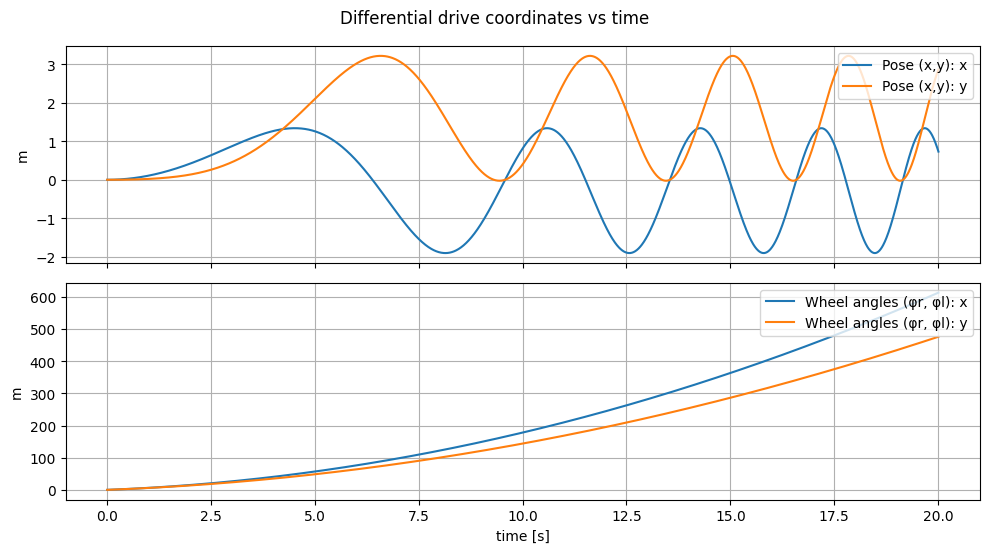

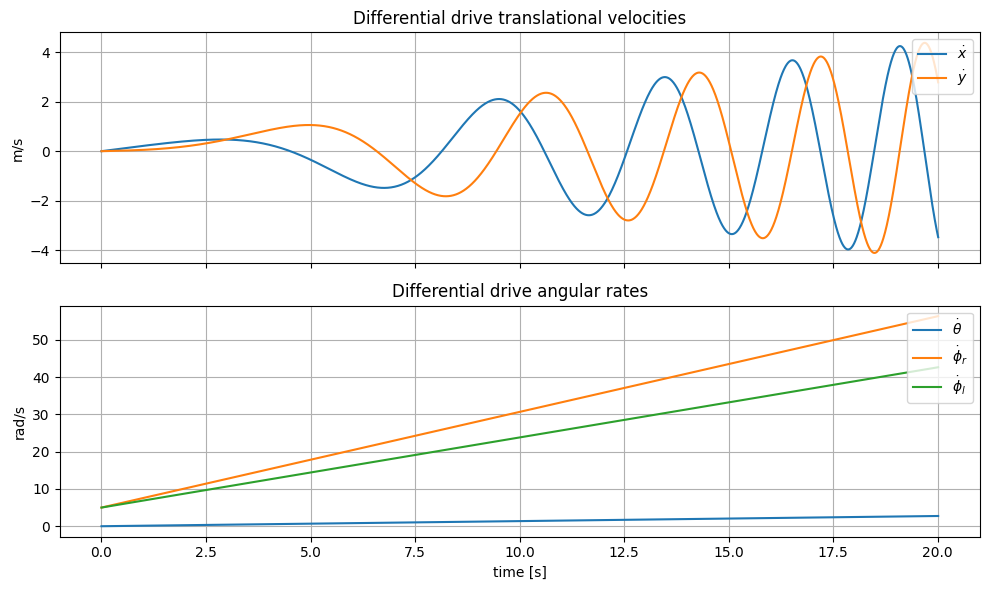

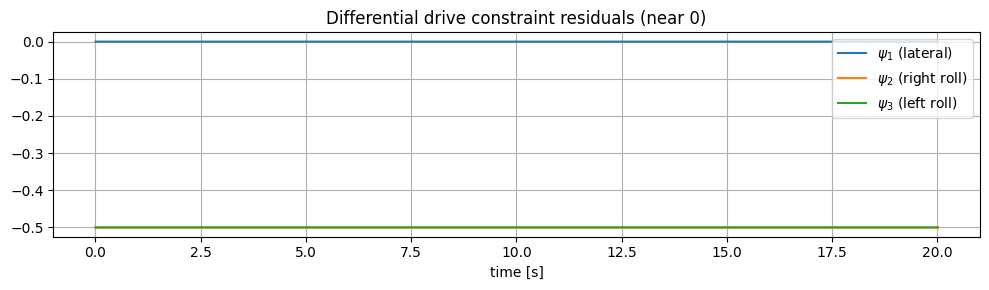

In [51]:
# Diff-drive plots: coordinates vs time
plot_points_xy(
    sol_dd.t,
    points=[(x_d, y_d), (φr_d, φl_d)],
    labels=["Pose (x,y)", "Wheel angles (φr, φl)"],
    title="Differential drive coordinates vs time",
)

# Velocities vs time (ẋ,ẏ) and (θ̇, φ̇r, φ̇l)
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(sol_dd.t, vx_d, label=r"$\dot x$")
axes[0].plot(sol_dd.t, vy_d, label=r"$\dot y$")
axes[0].set_ylabel("m/s")
axes[0].set_title("Differential drive translational velocities")
axes[0].legend(loc="upper right")

axes[1].plot(sol_dd.t, ω_d, label=r"$\dot\theta$")
axes[1].plot(sol_dd.t, φrd_d, label=r"$\dot\phi_r$")
axes[1].plot(sol_dd.t, φld_d, label=r"$\dot\phi_l$")
axes[1].set_ylabel("rad/s")
axes[1].set_xlabel("time [s]")
axes[1].set_title("Differential drive angular rates")
axes[1].legend(loc="upper right")
plt.tight_layout()

# Constraint checks
s = np.sin(θ_d)
c = np.cos(θ_d)
psi1 = -s * vx_d + c * vy_d
psi2 = c * vx_d + s * vy_d + (L / 2.0) * ω_d - rw * φrd_d
psi3 = c * vx_d + s * vy_d - (L / 2.0) * ω_d - rw * φld_d

fig, ax = plt.subplots(1, 1, figsize=(10, 3.0))
ax.plot(sol_dd.t, psi1, label=r"$\psi_1$ (lateral)")
ax.plot(sol_dd.t, psi2, label=r"$\psi_2$ (right roll)")
ax.plot(sol_dd.t, psi3, label=r"$\psi_3$ (left roll)")
ax.set_title("Differential drive constraint residuals (near 0)")
ax.set_xlabel("time [s]")
ax.legend(loc="upper right")
plt.tight_layout()
